In [1]:
import os
import sys
import json
import glob
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
sys.path.append("..")
from process.ifc_analysis_utils import *

warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
root = Path.cwd().parent
mixs = ["mix_37_235", "mix_55_532"]
metrics = ["F1_score", "G_mean"]

all_results = build_all_results(data_root= root/"experiments")
artifacts_table = build_artifacts_path_table(data_root=root/"experiments")

orig_table = build_original_data_path_table(data_root=root/"experiments")
orig_table = add_pos_paths(orig_table, pos_label=1)

✅ build_all_results 完成: 共11625行, baseline=3255, none=930, self_loop=7440


In [3]:
from utils.common import DATASETS, CLASSIFIERS
all_datasets = DATASETS
num_datasets = ['breast_cancer_coimbra', 'PIMA_diabetes']
cat_datasets = ['TCGA_InfoWithGrade', 'Thyroid_Diff','diabetes_risk_prediction']
mixed_datasets = ['framingham', 'hepatitis']

my_datasets = all_datasets
my_classifiers = CLASSIFIERS

## 分类结果展示

In [4]:
raw_table = build_raw_reference_table(all_results)

vae_only_summary = summarize_method_stats(all_results, "none_noft")   # 你要的独立汇总

extra_rows = [
    ("VAE-only", "none_noft", None, None),  
    ("VAE+FT",     "none_ft",   None, None),
    ("IFC",       "smote_ft",  "mix_55_532", 2),
]
main_table = build_comparison_table(all_results, extra_rows, mark_close_calls=True)

## TSNE 可视化

### 1. 定义数据集和相关内容

In [12]:
from utils.common import load_json
from process.visualization import *

#"Thyroid_Diff"
dataset = "framingham"
seed, fold = pick_representative_fold(all_results, dataset)
orig_row = orig_table[(orig_table["Dataset"]==dataset) & (orig_table["Seed"]==seed) & (orig_table["Fold"]==fold)].iloc[0]

datasets_info = load_json(root / "data/datasets_info.json")

numerical_cols = datasets_info[dataset]["numerical"]
categorical_cols = datasets_info[dataset]["categorical"]

feature_cols = numerical_cols + categorical_cols
X_train_real = pd.read_parquet(orig_row["X_train_path"])
preprocessor = build_preprocessor(X_train_real, numerical_cols, categorical_cols)  # 有现成encoder的话优先换成那个
real_df = pd.read_parquet(orig_row["X_train_pos_path"])

group_specs = [
    ("VAE-only", load_synthetic_stage(artifacts_table, dataset, seed, fold, "none_noft", stage="v0")),
    ("VAE + FT", load_synthetic_stage(artifacts_table, dataset, seed, fold, "none_ft", stage="__all_clusters__")),
    ("Self-Circulating v1", load_synthetic_stage(artifacts_table, dataset, seed, fold, "smote_ft", "mix_55_532", 3, "v1")),
    ("Self-Circulating v2", load_synthetic_stage(artifacts_table, dataset, seed, fold, "smote_ft", "mix_55_532", 3, "v2")),
    ("Self-Circulating v3", load_synthetic_stage(artifacts_table, dataset, seed, fold, "smote_ft", "mix_55_532", 3, "v3")),
    ("IFC (SMOTE_FT)", load_synthetic_stage(artifacts_table, dataset, seed, fold, "smote_ft", "mix_55_532", 3, "__fidelity__")),
] + [
    (m, load_synthetic_stage(artifacts_table, dataset, seed, fold, m, stage="__fidelity__"))
    for m in ["smote", "ctgan", "tvae", "forestdiffusion", "tabddpm", "tabkde"]
]

In [6]:
if False:
    combined = build_combined_embedding(real_df, group_specs, feature_cols, preprocessor)

    fig_evo = render_subplot_grid(
        combined, labels=["VAE-only", "VAE + FT", "Self-Circulating v1", 
                        "Self-Circulating v2", "Self-Circulating v3", "IFC (SMOTE_FT)"],
        show_labels=["VAE-only", "VAE + FT", "Self-Circulating v1", 
                    "Self-Circulating v2", "Self-Circulating v3", "IFC (SMOTE_FT)"],)

    fig_base = render_subplot_grid(
        combined, labels=["smote", "ctgan", "tvae", "forestdiffusion", "tabddpm", "tabkde"], #, "IFC (final)"
        show_labels=["SMOTE", "CTGAN", "TVAE", "ForestDiffusion", "TabDDPM", "TabKDE"],)

    fig_evo.savefig(root / 'results/pictures'/ f'{dataset}_ifc_evo_tsne.pdf', bbox_inches='tight')
    fig_base.savefig(root / 'results/pictures' / f'{dataset}_base_tsne.pdf', bbox_inches='tight')

## Kendall可视化

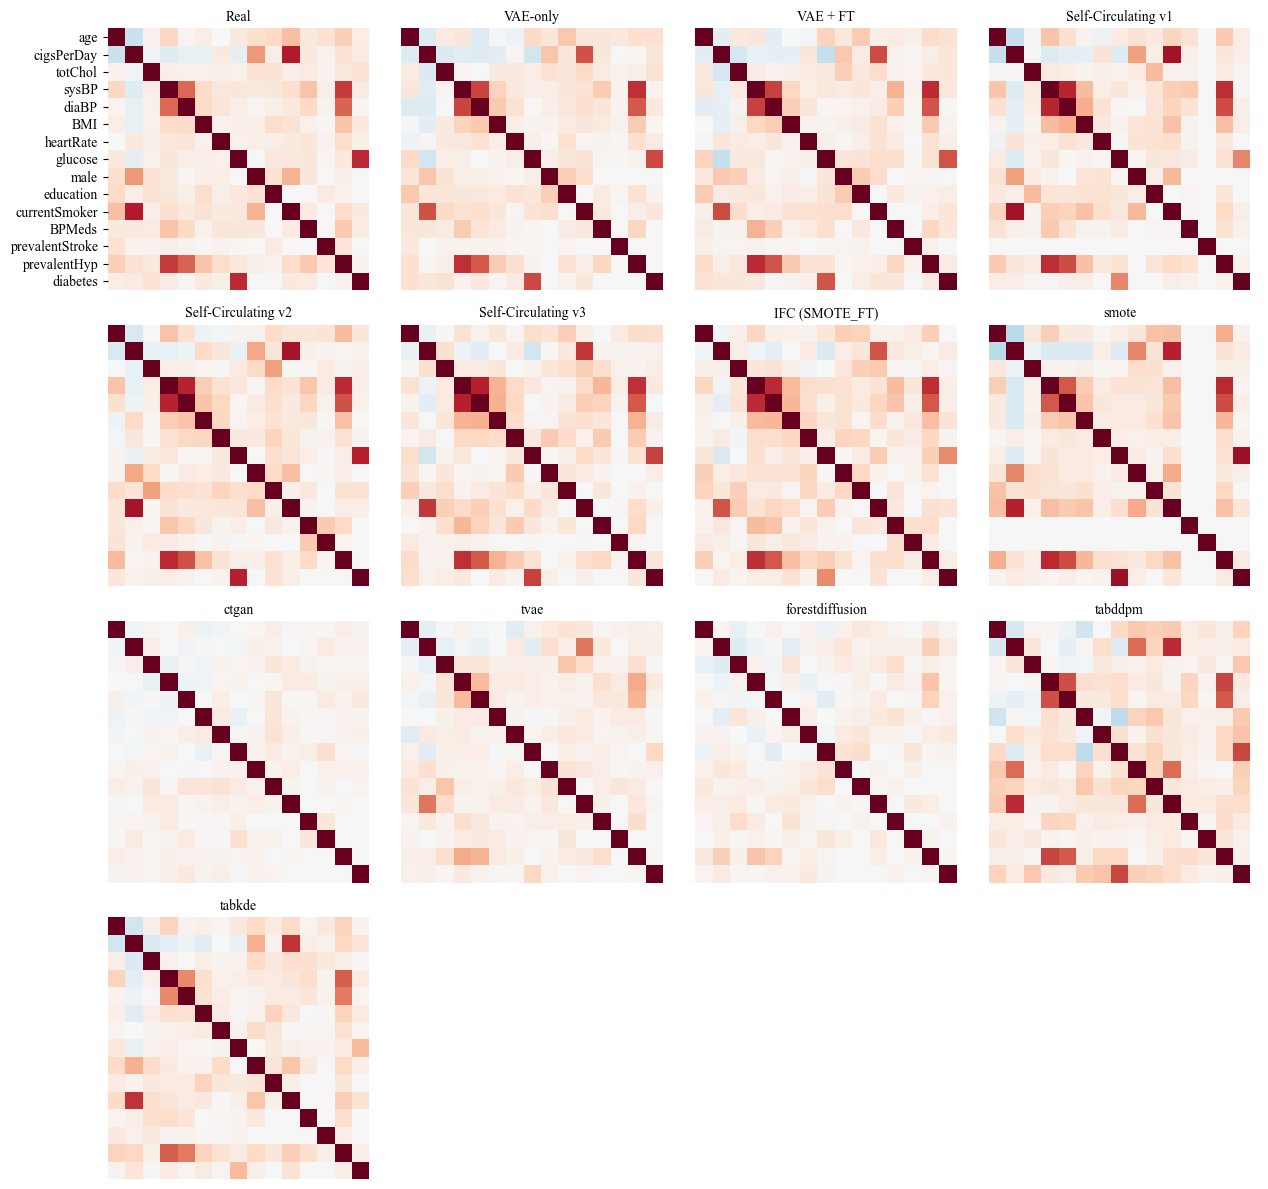

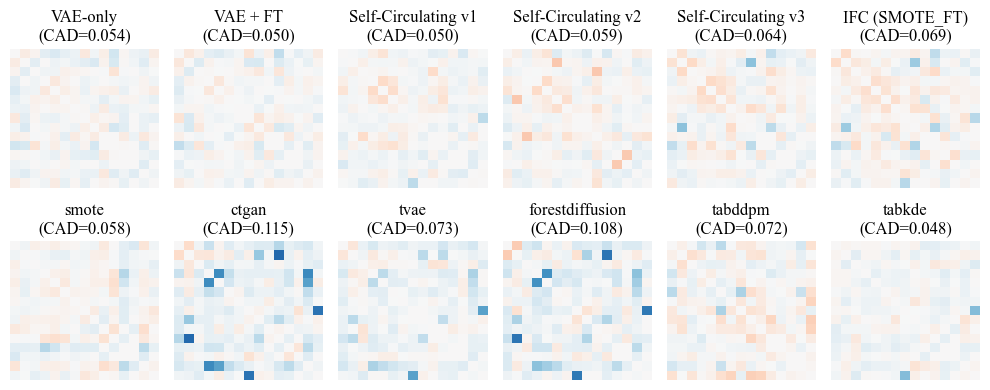

In [13]:
from process.visualization import plot_correlation_grid, plot_correlation_deviation_grid, correlation_deviation_summary


fig1 = plot_correlation_grid(real_df, group_specs, numerical_cols, categorical_cols)
fig2 = plot_correlation_deviation_grid(real_df, group_specs, numerical_cols, categorical_cols)
fig2.savefig(root/'results/pictures'/f'{dataset}_kendall_deviation_grid.pdf')
corr_summary = correlation_deviation_summary(real_df, group_specs, numerical_cols, categorical_cols)